# Задание 1: Анализ и прогнозирование временных рядов

## Задание 1: Исследование и статистический анализ временного ряда акций компаний Apple (AAPL) и Intel (INTC)

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# Настройка графиков
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

### Создание датасета
Загрузим дневные данные акция для Apple и Intel:

In [2]:
def get_price_data(ticker='WOOF'):
    tickerData = yf.Ticker(ticker)
    tickerDf = tickerData.history(start='2017-01-01')
    return tickerDf['Close']

aapl = get_price_data('AAPL')
intc = get_price_data('INTC')


print(f'Apple (AAPL) - записей: {len(aapl)}, диапазон: {aapl.index.min().date()} - {aapl.index.max().date()}')
print(f'Intel (INTC) - записей: {len(intc)}, диапазон: {intc.index.min().date()} - {intc.index.max().date()}')

Apple (AAPL) - записей: 2359, диапазон: 2017-01-03 - 2026-05-21
Intel (INTC) - записей: 2359, диапазон: 2017-01-03 - 2026-05-21


Проверим датасеты на пропуски:

In [3]:
dfs = {'Apple': aapl, 'Intel': intc}
for name, df in dfs.items():
    print(f'Пустых значений в датасете {name}: {df.isna().sum().sum()}')

Пустых значений в датасете Apple: 0
Пустых значений в датасете Intel: 0


### 1. Визуализация исходных временных рядов цен закрытия

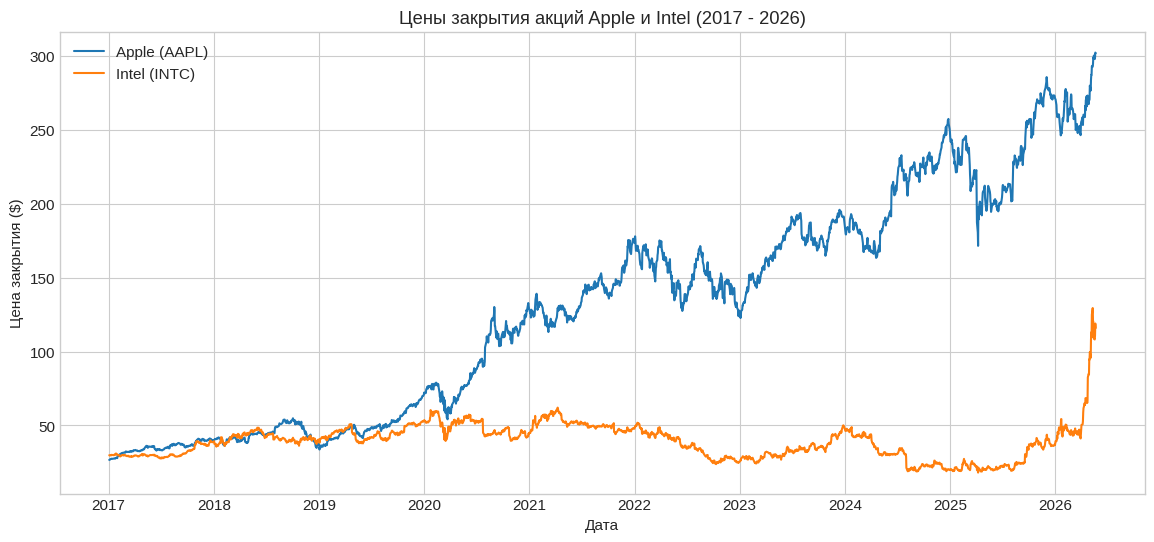

In [4]:
plt.figure(figsize=(14, 6))
plt.plot(aapl, label='Apple (AAPL)', color='tab:blue', linewidth=1.5)
plt.plot(intc, label='Intel (INTC)', color='tab:orange', linewidth=1.5)
plt.title('Цены закрытия акций Apple и Intel (2017 - 2026)')
plt.xlabel('Дата')
plt.ylabel('Цена закрытия ($)')
plt.legend()
plt.show()

Визуально наблюдается нестационарность ряда Apple по причине долгосрочного восходящего тренда. Ряд Intel не имеет однозначного тренда, но у него присутствует цикличность - дисперсия и среднее меняются во времени.

### 2. Расчет основных статистик для цен закрытия и их интерпретация

Рассчитаем ключевые описательные статистики

In [5]:
stats_comparison = pd.concat([
    aapl.describe().rename('Apple (AAPL)'), 
    intc.describe().rename('Intel (INTC)')
], axis=1)
stats_comparison

,Apple (AAPL),Intel (INTC)
count,2359.000000,2359.000000
mean,129.966925,39.249721
std,74.478456,12.024628
min,26.691330,18.129999
25%,49.453548,29.997052
50%,137.523926,40.388950
75%,183.804451,46.177879
max,302.250000,129.440002


Акции Apple демонстрируют огромный размах цен, что отражается в высоком стандартном отклонении. Это следствие сильного долгосрочного восходящего тренда. В то же время Intel имеет более узкий диапазон цен, меньшее стандартное отклонение и торгуется преимущественно в широком боковом коридоре с периодическими локальными взлетами и просадками.

### 3. Декомпозиция временного ряда (тренд, сезонность, шум)

Разложим временные ряды на три компоненты с помощью аддитивной модели. Поскольку на фондовом рынке в году примерно 252 торговых дня, используем этот период для поиска годовой сезонности.

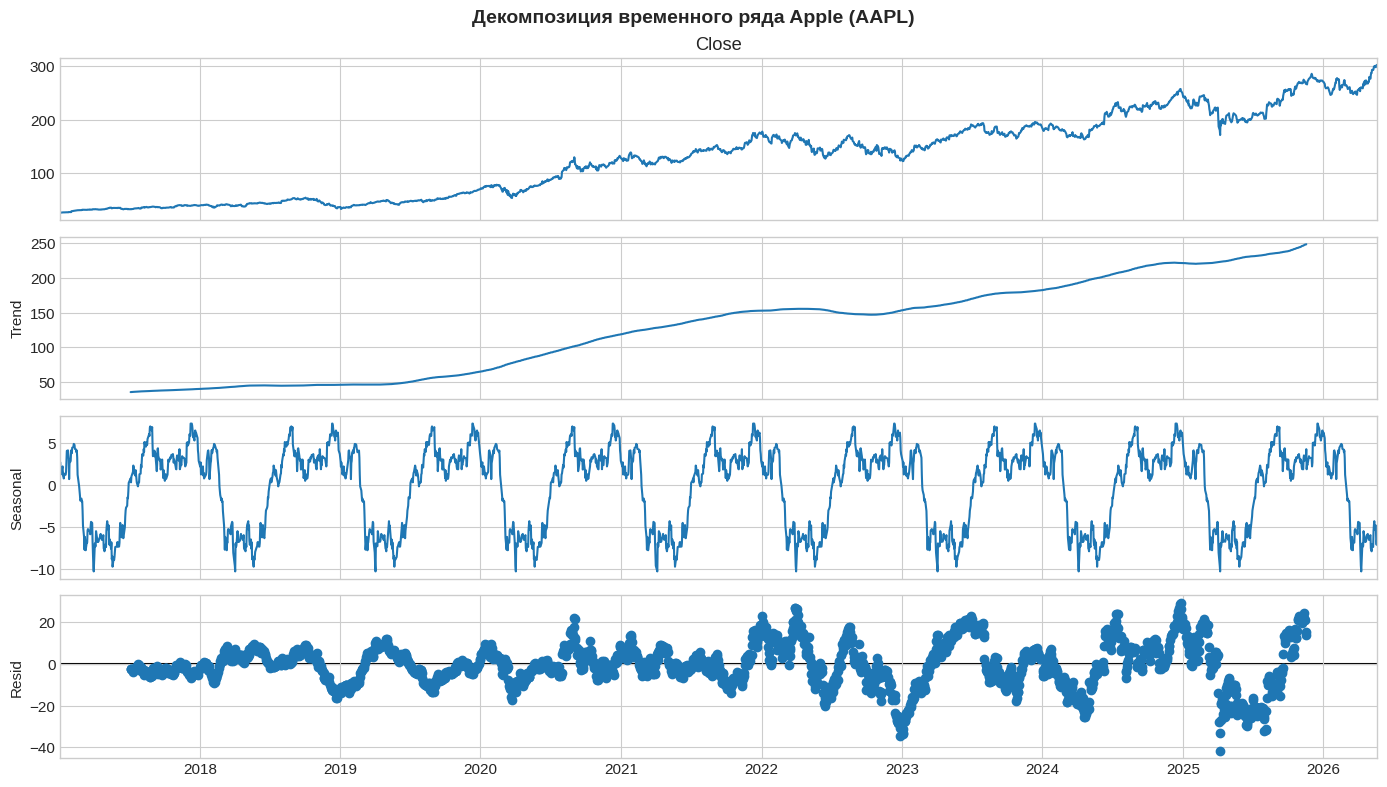

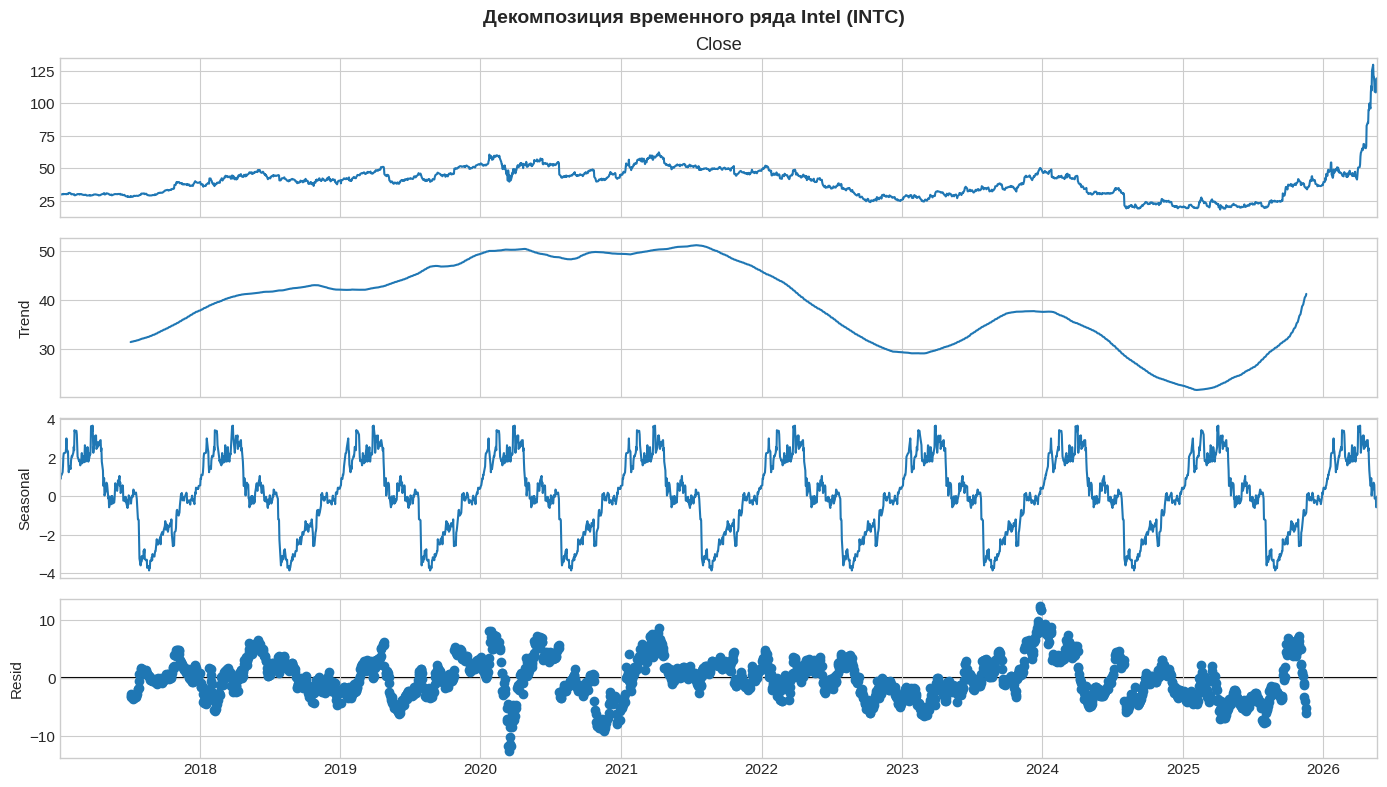

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

def plot_decomposition(series, title):
    # period=252 торговых дня в году
    decomp = seasonal_decompose(series, model='additive', period=252)
    fig = decomp.plot()
    fig.set_size_inches(14, 8)
    fig.suptitle(title, fontsize=14, fontweight='bold')
    fig.tight_layout()
    fig.subplots_adjust(top=0.92)
    plt.show()

plot_decomposition(aapl, 'Декомпозиция временного ряда Apple (AAPL)')
plot_decomposition(intc, 'Декомпозиция временного ряда Intel (INTC)')

Основную долю в изменение цены Apple вносит долгосрочный восходящий тренд, а случайный шум создает лишь небольшие отклонения от этого тренда.\
В то же время у Intel нет единого долгосрочного тренда, а случайный шум создает более значимые колебания цены по сравнению с Apple.\
Для обеих компаний амплитуда сезонности ничтожно мала по сравнению с ценой акций, это доказывает что фондовый рынок не имеет предсказуемых внутригодовых циклов.

### 4. Автокорреляционный анализ (ACF и PACF) рядов

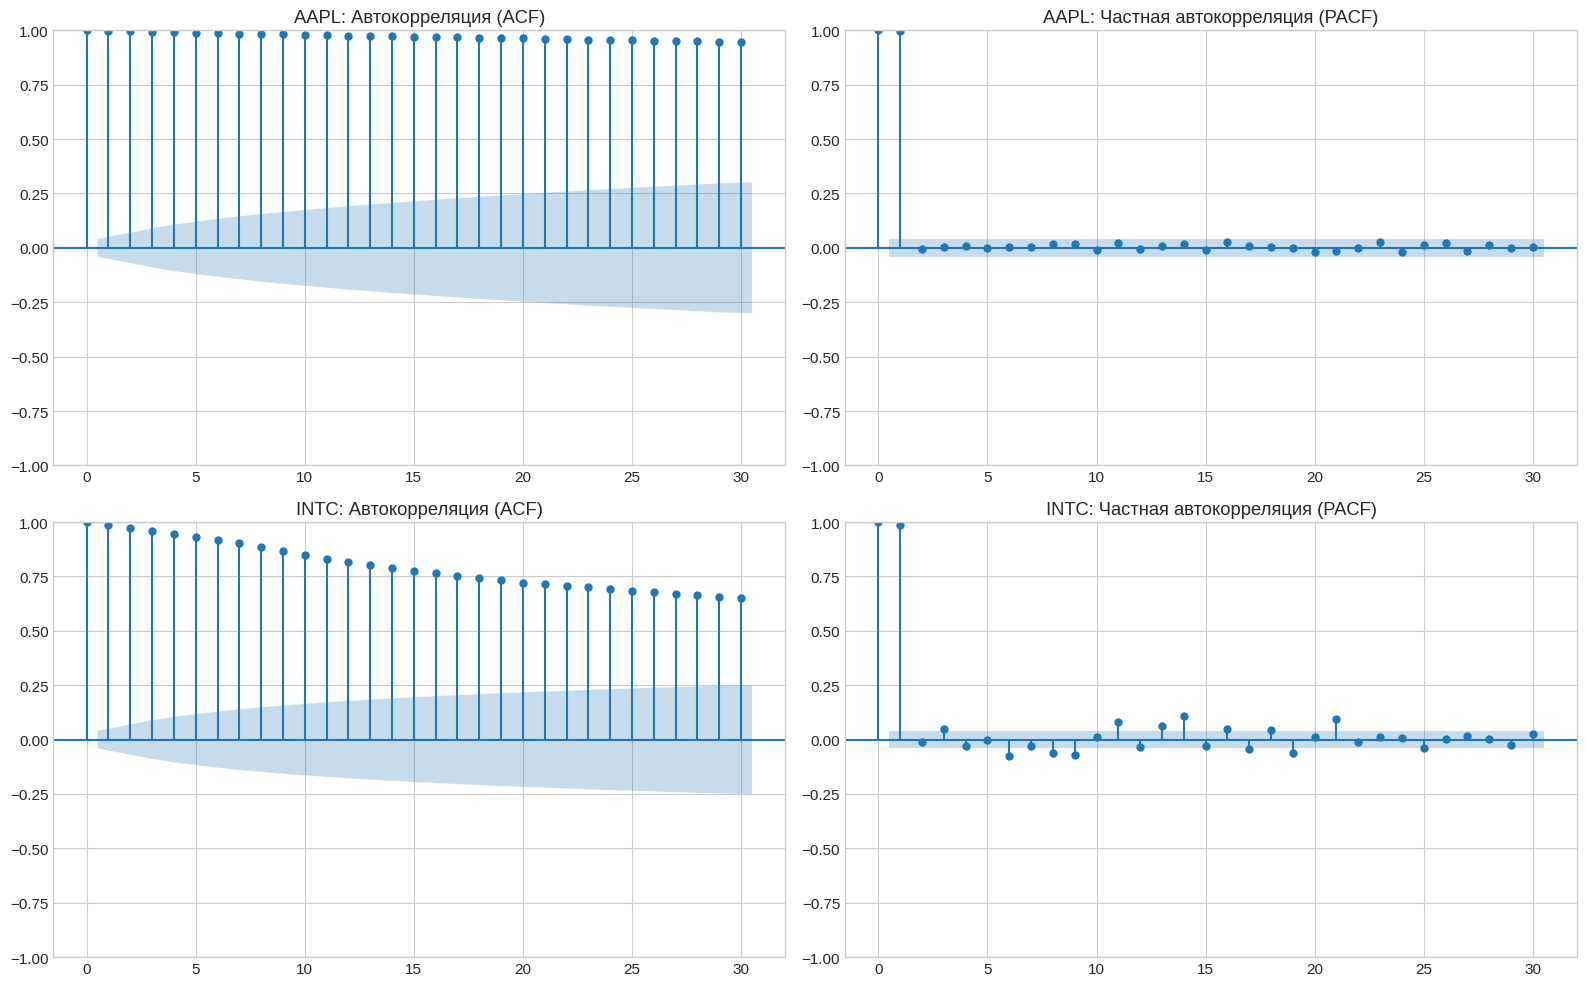

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Apple
plot_acf(aapl, ax=axes[0, 0], lags=30, title='AAPL: Автокорреляция (ACF)')
plot_pacf(aapl, ax=axes[0, 1], lags=30, title='AAPL: Частная автокорреляция (PACF)')

# Intel
plot_acf(intc, ax=axes[1, 0], lags=30, title='INTC: Автокорреляция (ACF)')
plot_pacf(intc, ax=axes[1, 1], lags=30, title='INTC: Частная автокорреляция (PACF)')

plt.tight_layout()
plt.show()

Разница в графиках ACF наглядно подтверждает различия в структуре рядов: крайне медленное затухание ACF у Apple обусловлено сильным восходящим трендом, в то время как более быстрое затухание ACF у Intel отражает отсутствие единого тренда и наличие микро-циклов.
Графики PACF показывают почти нулевую зависимость текущей цены от исторических значений, кроме первого дня. У Intel зависимость от предыдущих дней больше из-за более высокой волатильности.
Также на графиках автокорреляции отсутсвуют периодические всплески через равные интервалы, что показывает отсутствие сезонности.

### 5. Тестирование на стационарность (тест Дики-Фуллера)

Проверим гипотезу о наличии единичного корня (нестационарности) с помощью теста ADF (Augmented Dickey-Fuller).
- **Нулевая гипотеза ($H_0$):** ряд нестационарен (имеет единичный корень).
- **Альтернативная гипотеза ($H_1$):** ряд стационарен (нет единичного корня).

Если статистика теста находится левее критического значения (p-value < 0.05), мы отвергаем $H_0$ и считаем ряд стационарным.

In [8]:
def adf_test(series, name):
    result = adfuller(series, autolag='AIC')
    print(f'=== ADF Test for {name} ===')
    print(f'Test Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print(f'Lags Used: {result[2]}')
    print(f'Observations Used: {result[3]}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.4f}')
    if result[1] < 0.05:
        print("Результат: Отвергаем H0. Ряд СТАЦИОНАРЕН (p < 0.05)")
    else:
        print("Результат: Не удалось отвергнуть H0. Ряд НЕСТАЦИОНАРЕН (p >= 0.05)")
    print('-' * 40)

adf_test(aapl, 'Apple (AAPL) Prices')
adf_test(intc, 'Intel (INTC) Prices')

=== ADF Test for Apple (AAPL) Prices ===
Test Statistic: 0.1930
p-value: 0.9719
Lags Used: 0
Observations Used: 2358
Critical Values:
   1%: -3.4331
   5%: -2.8628
   10%: -2.5674
Результат: Не удалось отвергнуть H0. Ряд НЕСТАЦИОНАРЕН (p >= 0.05)
----------------------------------------
=== ADF Test for Intel (INTC) Prices ===
Test Statistic: -0.2682
p-value: 0.9299
Lags Used: 18
Observations Used: 2340
Critical Values:
   1%: -3.4331
   5%: -2.8628
   10%: -2.5674
Результат: Не удалось отвергнуть H0. Ряд НЕСТАЦИОНАРЕН (p >= 0.05)
----------------------------------------


Для исходных цен закрытия обеих акций значение p−value оказалось значительно больше критического порога α = 0.05. На основании этого мы не можем отвергнуть нулевую гипотезу. Тест доказал, что оба исходных временных ряда являются нестационарными. В текущем виде их нельзя использовать для прогнозирования.

### 6. Приведение временных рядов к стационарному виду

Так как оба ряда цен закрытия нестационарны, применим к ним трансформации:\
**Логарифмирование** для сглаживания экспоненциального роста тренда и стабилизации дисперсии:

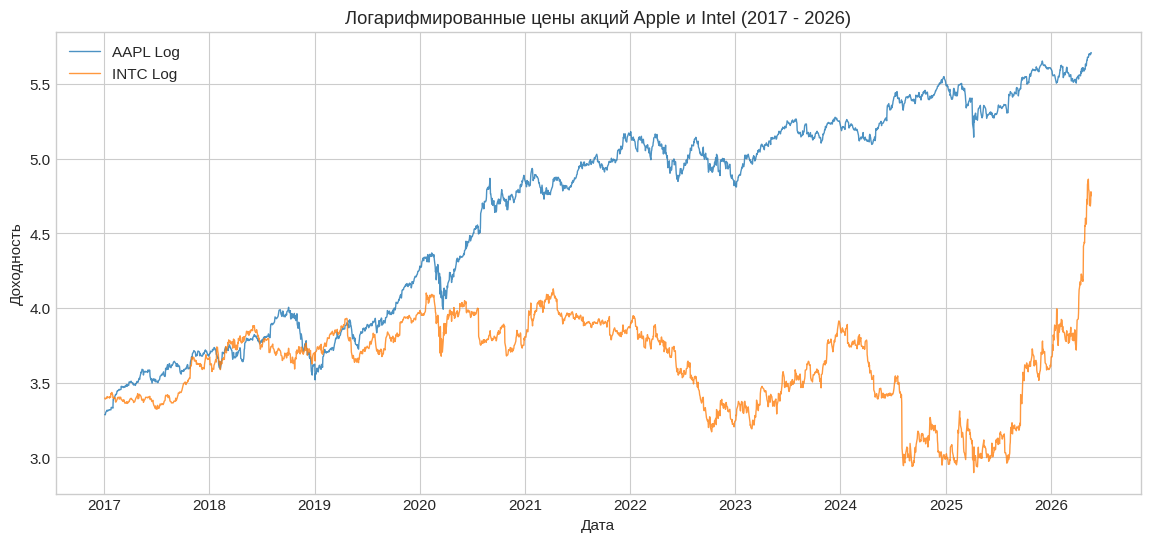

In [9]:
aapl_log = np.log(aapl)
intc_log = np.log(intc)

plt.figure(figsize=(14, 6))
plt.plot(aapl_log, label='AAPL Log', color='tab:blue', alpha=0.8, linewidth=1)
plt.plot(intc_log, label='INTC Log', color='tab:orange', alpha=0.8, linewidth=1)
plt.title('Логарифмированные цены акций Apple и Intel (2017 - 2026)')
plt.xlabel('Дата')
plt.ylabel('Доходность')
plt.legend()
plt.show()

**Дифференцирование** для удаления тренда:

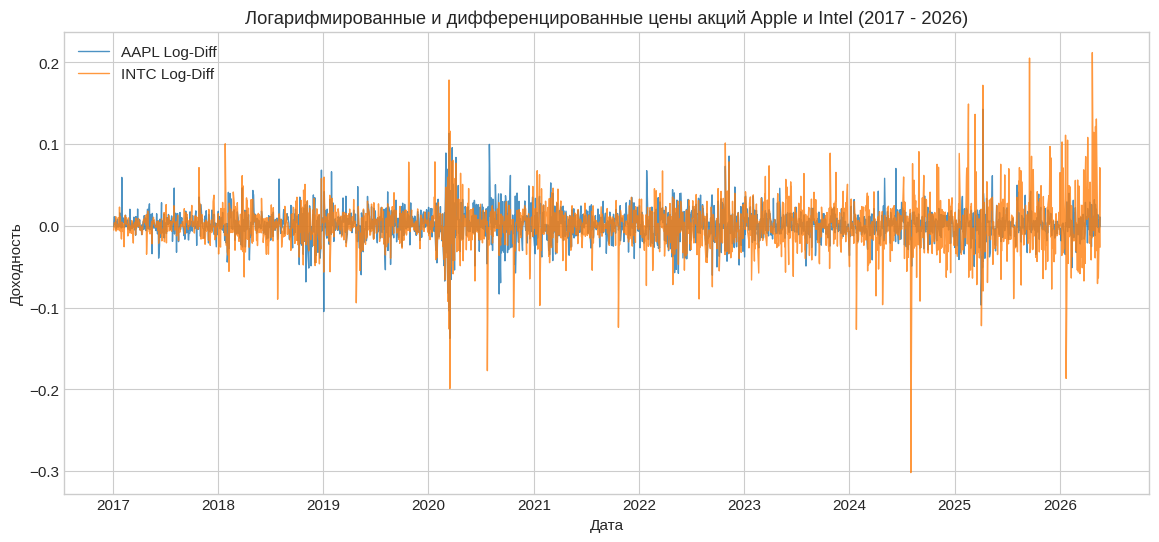

In [10]:
aapl_diff = aapl_log.diff().dropna()
intc_diff = intc_log.diff().dropna()

plt.figure(figsize=(14, 6))
plt.plot(aapl_diff, label='AAPL Log-Diff', color='tab:blue', alpha=0.8, linewidth=1)
plt.plot(intc_diff, label='INTC Log-Diff', color='tab:orange', alpha=0.8, linewidth=1)
plt.title('Логарифмированные и дифференцированные цены акций Apple и Intel (2017 - 2026)')
plt.xlabel('Дата')
plt.ylabel('Доходность')
plt.legend()
plt.show()

Новый график колеблется вокруг нулевой оси, долгосрочные тренды полностью удалены, а цены приведены к относительным изменениям.

#### Повторный тест Дики-Фуллера на трансформированных рядах

Проверим, стали ли новые ряды стационарными.

In [11]:
adf_test(aapl_diff, 'AAPL Log-Returns')
adf_test(intc_diff, 'INTC Log-Returns')

=== ADF Test for AAPL Log-Returns ===
Test Statistic: -15.9504
p-value: 0.0000
Lags Used: 8
Observations Used: 2349
Critical Values:
   1%: -3.4331
   5%: -2.8628
   10%: -2.5674
Результат: Отвергаем H0. Ряд СТАЦИОНАРЕН (p < 0.05)
----------------------------------------
=== ADF Test for INTC Log-Returns ===
Test Statistic: -12.4434
p-value: 0.0000
Lags Used: 15
Observations Used: 2342
Critical Values:
   1%: -3.4331
   5%: -2.8628
   10%: -2.5674
Результат: Отвергаем H0. Ряд СТАЦИОНАРЕН (p < 0.05)
----------------------------------------


Повторный тест Дики-Фуллера для логарифмических доходностей показал p−value≈0.0000, что намного меньше порогового значения 0.05. Следовательно, мы с уверенностью отвергаем нулевую гипотезу о наличии единичного корня. Преобразование успешно привело временные ряды к стационарному виду

### 7. ACF и PACF стационарных рядов

Построим автокорреляционные графики для трансформированных рядов. Для стационарного ряда автокорреляция должна быстро падать до нуля, что говорит об отсутствии длинной памяти в изменениях цен.

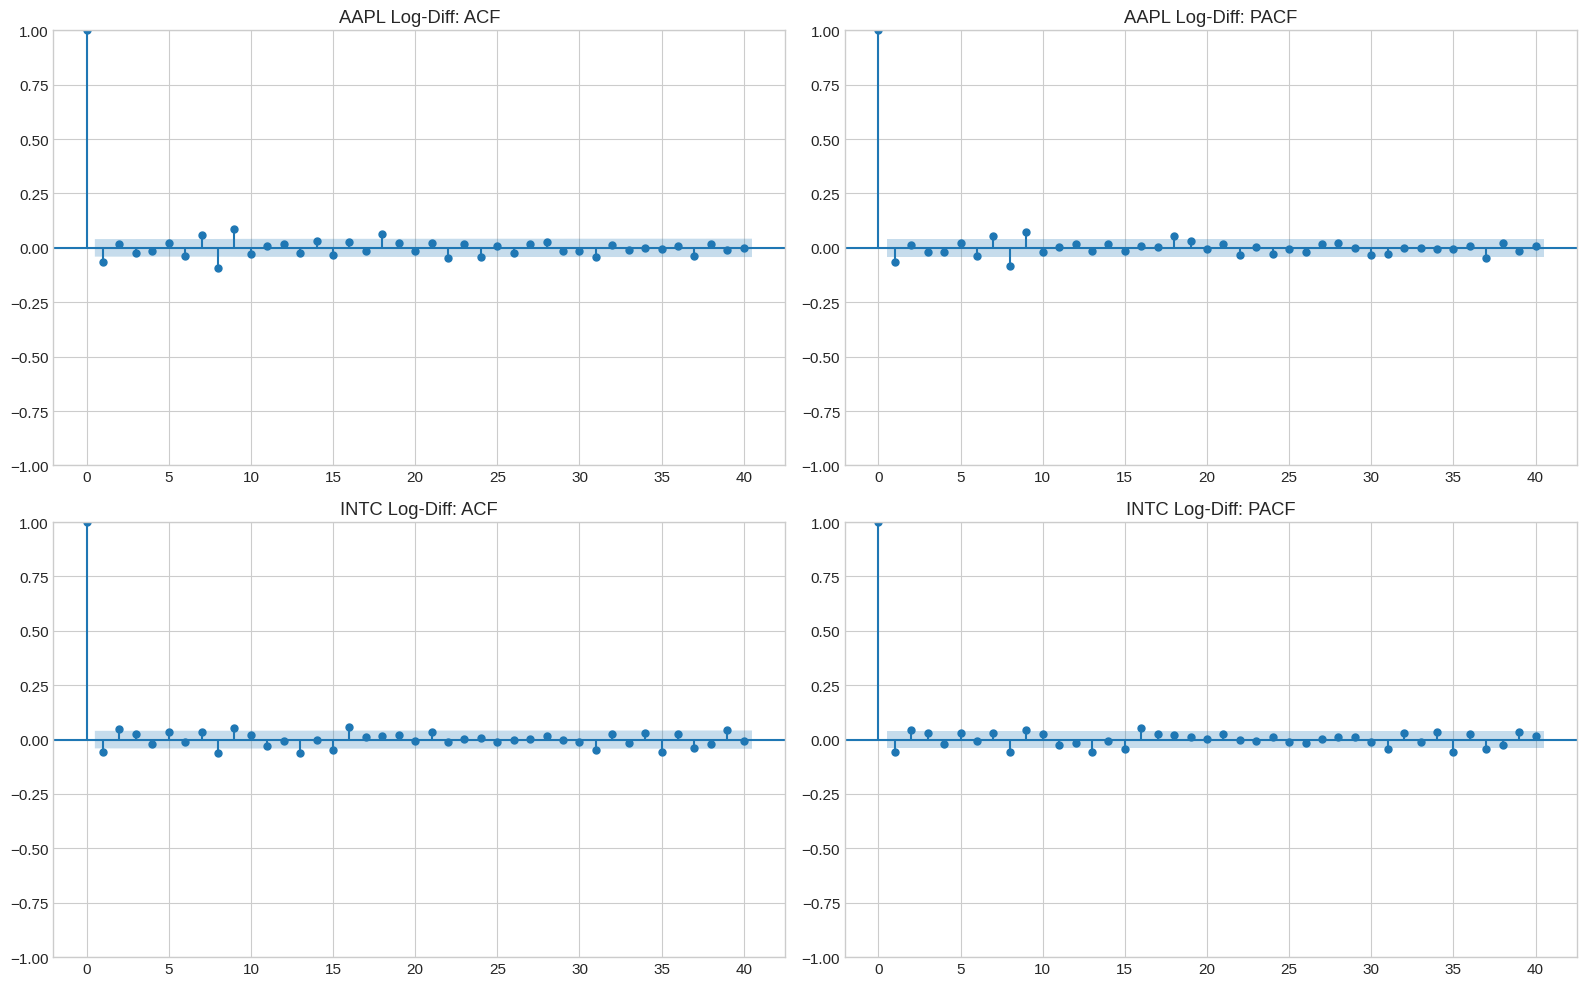

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Apple
plot_acf(aapl_diff, ax=axes[0, 0], lags=40, title='AAPL Log-Diff: ACF')
plot_pacf(aapl_diff, ax=axes[0, 1], lags=40, title='AAPL Log-Diff: PACF')

# Intel
plot_acf(intc_diff, ax=axes[1, 0], lags=40, title='INTC Log-Diff: ACF')
plot_pacf(intc_diff, ax=axes[1, 1], lags=40, title='INTC Log-Diff: PACF')

plt.tight_layout()
plt.show()

### Вывод:
Проведенный анализ показал, что исходные ряды цен акций (Apple и Intel) являются нестационарными процессами типа "случайное блуждание" с отсутствием предсказуемой годовой сезонности. Использовать их в сыром виде для прогнозирования математически некорректно. Однако применение логарифмирования и дифференцирования успешно удаляет тренды и стабилизирует дисперсию, превращая ряды в стационарный белый шум. Полученные стационарные ряды полностью готовы для построения моделей.

## Задание 2: Прогнозирование временного ряда акций Apple (AAPL)

### 1. Обоснование выбора модели

На основе разведочного анализа было доказано, что цены закрытия Apple являются нестационарным временным рядом с сильным восходящим трендом и без признаков годовой сезонности.

Исходя из этого, в качестве оптимальной модели выбрана ARIMA. В отличие от методов простого экспоненциального сглаживания или скользящих средних, ARIMA изначально математически создана для работы с нестационарными данными. Параметр интегрированности (d) позволяет модели автоматически дифференцировать ряд, а авторегрессионная часть (p,q) улавливает краткосрочную инерцию рынка. Использование сезонных моделей (SARIMA) отвергнуто, чтобы избежать проблемы переобучения на случайном историческом шуме (так как сезонность отсутствует).

Основной метрикой выбрана MAPE (Mean Absolute Percentage Error). Поскольку акция Apple выросла с 30 до 300, абсолютные метрики (MAE, RMSE) будут давать искаженную картину (разный масштаб ошибок в разные годы). MAPE решает эту проблему, оценивая ошибку прогноза в универсальных процентах.

### 2. Подбор параметров и оценка качества модели ARIMA используя кросс-валидацию с помощью TimeSeriesSplit

Используем скользящую валидацию на временных рядах (`TimeSeriesSplit`) с 5 фолдами. Это исключает заглядывание в будущее при обучении.

In [30]:
from sklearn.model_selection import TimeSeriesSplit
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
# Создаем массив значений для валидации
X = aapl.values
tscv = TimeSeriesSplit(n_splits=5)
arima_mape_list = []
print('Начало кросс-валидации (ARIMA)...')
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    train, test = X[train_idx], X[test_idx]
    
    # Обучение ARIMA через auto_arima
    arima_model = auto_arima(train, start_p=0, start_q=0, max_p=3, max_q=3, d=1, 
                             seasonal=False, error_action='ignore', suppress_warnings=True)
    arima_pred = arima_model.predict(n_periods=len(test))
    
    # Расчет метрики MAPE
    a_mape = mean_absolute_percentage_error(test, arima_pred)
    arima_mape_list.append(a_mape)
    
    print(f'Фолд {fold+1}: MAPE: {a_mape*100:.2f}% (подобранные параметры ARIMA: {arima_model.order})')
    
print(f'\nИтоговая средняя ошибка MAPE по всем фолдам: {np.mean(arima_mape_list)*100:.2f}%')

Начало кросс-валидации (ARIMA)...
Фолд 1: MAPE: 16.21% (подобранные параметры ARIMA: (0, 1, 0))
Фолд 2: MAPE: 20.92% (подобранные параметры ARIMA: (0, 1, 0))
Фолд 3: MAPE: 16.20% (подобранные параметры ARIMA: (1, 1, 0))
Фолд 4: MAPE: 6.54% (подобранные параметры ARIMA: (0, 1, 1))
Фолд 5: MAPE: 7.98% (подобранные параметры ARIMA: (0, 1, 0))

Итоговая средняя ошибка MAPE по всем фолдам: 13.57%


Проверка качества на отложенных выборках через TimeSeriesSplit показала высокую стабильность: средняя ошибка MAPE составила 13.57%. Важнейшим результатом стало то, что алгоритм почти всегда выбирал порядок (0, 1, 0). Это свидетельство того, что цены ведут себя как случайное блуждание.

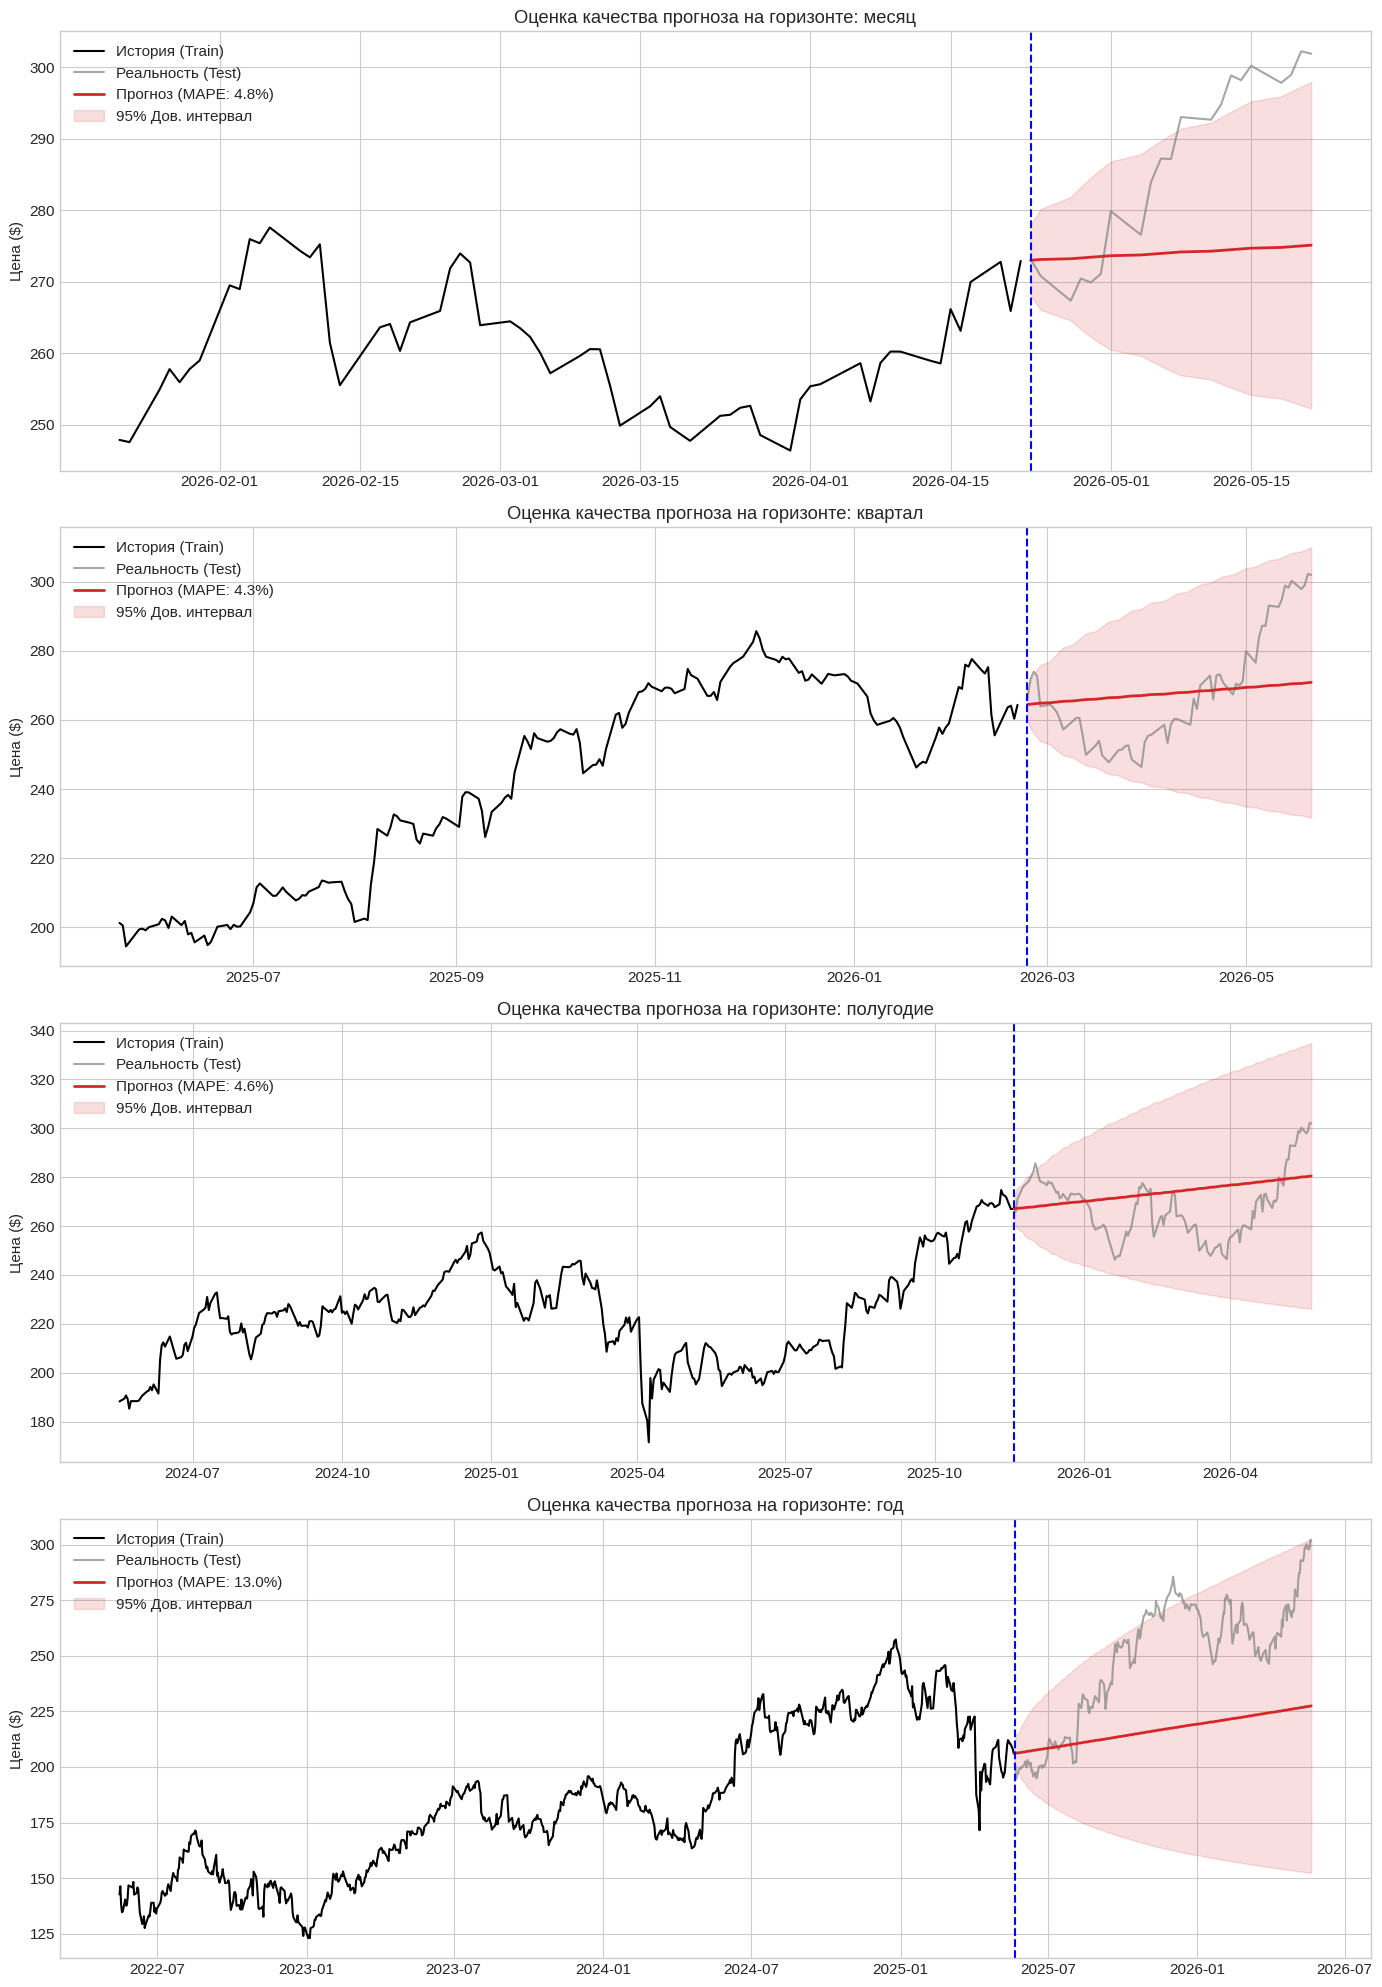

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_percentage_error

horizons = {
    'месяц': 21, 
    'квартал': 63, 
    'полугодие': 126, 
    'год': 252
}


fig, axes = plt.subplots(4, 1, figsize=(14, 20))
axes = axes.flatten()

for idx, (label, n_test) in enumerate(horizons.items()):
    ax = axes[idx]
    
    # Отрезаем нужный хвост
    train_data = aapl.iloc[:-n_test]
    test_data = aapl.iloc[-n_test:]
    
    # Обучаем модель именно до начала этого хвоста
    model = auto_arima(train_data.values, start_p=0, start_q=0, max_p=3, max_q=3, d=1, 
                       seasonal=False, error_action='ignore', suppress_warnings=True)
    
    # Строим прогноз на длину хвоста
    forecast, conf_int = model.predict(n_periods=n_test, return_conf_int=True, alpha=0.05)
    
    # Считаем метрику для данного горизонта
    mape = mean_absolute_percentage_error(test_data.values, forecast)
    
    # Рисуем историю (берем кусок до хвоста для наглядной стыковки)
    history_len = n_test * 3
    history_plot = aapl.iloc[-(n_test + history_len):-n_test]
    ax.plot(history_plot.index, history_plot.values, color='black', label='История (Train)')
    
    # Рисуем реальный хвост
    ax.plot(test_data.index, test_data.values, color='gray', linestyle='-', alpha=0.7, label='Реальность (Test)')
    
    # Рисуем прогноз и доверительный интервал
    ax.plot(test_data.index, forecast, color='tab:red', linewidth=2, label=f'Прогноз (MAPE: {mape*100:.1f}%)')
    ax.fill_between(test_data.index, conf_int[:, 0], conf_int[:, 1], color='tab:red', alpha=0.15, label='95% Дов. интервал')
    
    # Отмечаем точку старта прогноза
    ax.axvline(x=test_data.index[0], color='blue', linestyle='--')
    
    ax.set_title(f'Оценка качества прогноза на горизонте: {label}')
    ax.set_ylabel('Цена ($)')
    
    # Легенда теперь выводится на каждом графике
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# Обучаем лучшую модель (ARIMA) на всем объеме данных
final_arima = auto_arima(intc.values, start_p=0, start_q=0, max_p=3, max_q=3, d=1, 
                         seasonal=False, error_action='ignore', suppress_warnings=True)
print(f'Оптимальная модель для финального прогноза: ARIMA{final_arima.order}')

# Временные горизонты
horizons = {'1 Месяц (30 дней)': 30, '1 Квартал (90 дней)': 90, '1 Полугодие (180 дней)': 180, '1 Год (365 дней)': 365}

predictions = {}
conf_intervals = {}

for name, h in horizons.items():
    pred, conf = final_arima.predict(n_periods=h, return_conf_int=True, alpha=0.05) # 95% доверительный интервал
    predictions[name] = pred
    conf_intervals[name] = conf
    print(f'Построен прогноз для горизонта {name}: последнее прогнозируемое значение = {pred[-1]:.2f}')

### Вывод:

Модель ARIMA хорошо уловила общий растущий тренд акций Apple и показала границы рисков (доверительные интервалы). Однако долгосрочные прогнозы, опирающиеся исключительно на прошлые цены, не способны предвидеть реальные рыночные шоки и внезапные новости. Поэтому в реальной торговле такие математические модели должны применяться строго в связке с фундаментальным экономическим анализом.